<a href="https://colab.research.google.com/github/thomafury/DeepNueralNetwork/blob/main/Network_Intrusion_Detection_DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


#Defining Column name

In [80]:
columns = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes',
'land','wrong_fragment','urgent','hot','num_failed_logins',
'logged_in','num_compromised','root_shell','su_attempted',
'num_root','num_file_creations','num_shells','num_access_files',
'num_outbound_cmds','is_host_login','is_guest_login',
'count','srv_count','serror_rate','srv_serror_rate',
'rerror_rate','srv_rerror_rate','same_srv_rate',
'diff_srv_rate','srv_diff_host_rate','dst_host_count',
'dst_host_srv_count','dst_host_same_srv_rate',
'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate',
'dst_host_srv_rerror_rate','attack','difficulty'
]

#Load Dataset

In [81]:
train_df = pd.read_csv(
    "KDDTrain+.txt",
    names=columns
)

test_df = pd.read_csv(
    "KDDTest+.txt",
    names=columns
)

print(train_df.shape)
print(test_df.shape)

(125973, 43)
(22544, 43)


#Data Exploration

In [82]:
train_df.head()
train_df.info()
train_df.describe()
train_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


#Explore attack cases

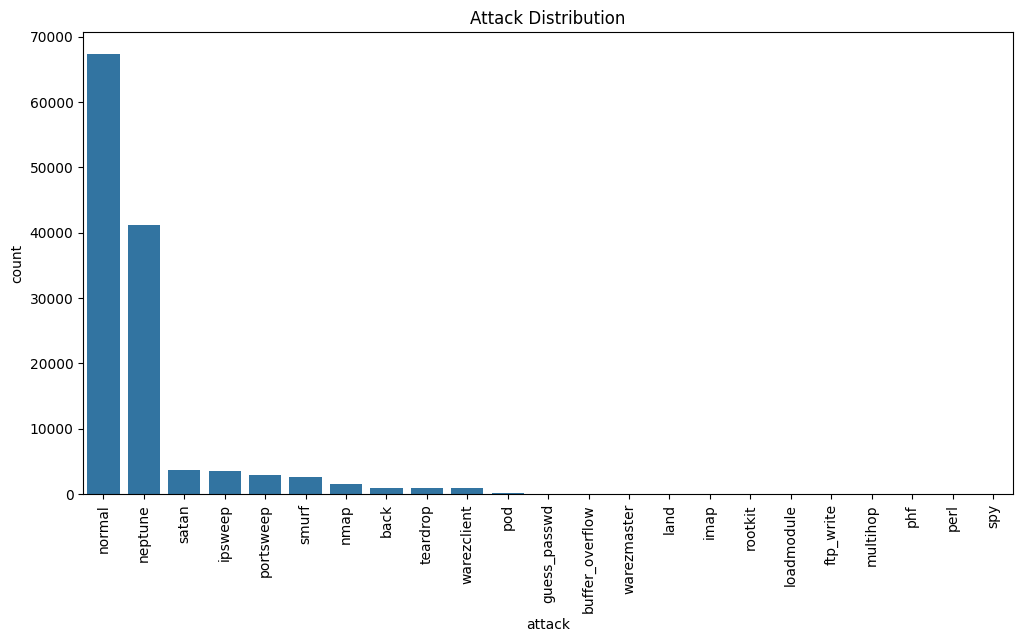

In [83]:
train_df['attack'].value_counts()
plt.figure(figsize=(12,6))

sns.countplot(
    x=train_df['attack'],
    order=train_df['attack'].value_counts().index
)

plt.xticks(rotation=90)
plt.title("Attack Distribution")
plt.show()

Convert to 5 main classes

In [84]:
def attack_category(attack):

    dos = [
        'back','land','neptune','pod','smurf',
        'teardrop','mailbomb','apache2',
        'processtable','udpstorm'
    ]

    probe = [
        'satan','ipsweep','nmap',
        'portsweep','mscan','saint'
    ]

    r2l = [
        'guess_passwd','ftp_write','imap',
        'phf','multihop','warezmaster',
        'warezclient','spy','xlock',
        'xsnoop','snmpguess',
        'snmpgetattack',
        'httptunnel',
        'sendmail',
        'named',
        'worm'
    ]

    u2r = [
        'buffer_overflow',
        'loadmodule',
        'rootkit',
        'perl',
        'sqlattack',
        'xterm',
        'ps'
    ]

    if attack == 'normal':
        return 'normal'
    elif attack in dos:
        return 'dos'
    elif attack in probe:
        return 'probe'
    elif attack in r2l:
        return 'r2l'
    elif attack in u2r:
        return 'u2r'
    else:
        return 'other'

In [85]:
train_df['attack_class'] = train_df['attack'].apply(attack_category)
test_df['attack_class'] = test_df['attack'].apply(attack_category)

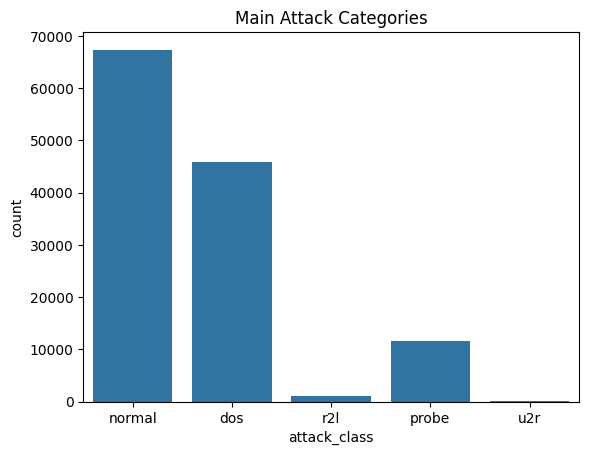

In [86]:
sns.countplot(
    x=train_df['attack_class']
)

plt.title("Main Attack Categories")
plt.show()

Why is neptune not a main class?

The dataset contains specific attack names such as:

neptune
smurf
teardrop
satan
nmap
guess_passwd
buffer_overflow
...

These are individual attack types.

For machine learning research, these attack types are usually grouped into 5 broader categories:

Main Class	Example Attacks
normal	normal
dos	neptune, smurf, teardrop, back, land
probe	satan, nmap, portsweep, ipsweep
r2l	guess_passwd, ftp_write, warezclient
u2r	buffer_overflow, rootkit, perl

In [87]:
train_df['attack'].value_counts().head(20)

,count
attack,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931
smurf,2646
nmap,1493
back,956
teardrop,892


Important Observation for Your Report

Look at this:

normal = 67,343
u2r ≈ 52

This is a severely imbalanced dataset.

This gives you excellent discussion points later.

You can write:

The NSL-KDD dataset exhibits significant class imbalance. While the Normal class contains more than 67,000 observations, the U2R category contains fewer than 100 samples. Such imbalance can bias the classifier toward majority classes and therefore appropriate evaluation metrics beyond simple accuracy are required.

Encode Features

In [88]:
train_df[['protocol_type','service','flag']].head()

,protocol_type,service,flag
0,tcp,ftp_data,SF
1,udp,other,SF
2,tcp,private,S0
3,tcp,http,SF
4,tcp,http,SF


ONE-HOT Encode

In [89]:
categorical_cols = [
    'protocol_type',
    'service',
    'flag'
]

train_df = pd.get_dummies(
    train_df,
    columns=categorical_cols
)

test_df = pd.get_dummies(
    test_df,
    columns=categorical_cols
)

Align Train and Test Columns

In [90]:
train_df, test_df = train_df.align(
    test_df,
    join='left',
    axis=1,
    fill_value=0
)

Encode Target Variable

In [91]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(
    train_df['attack_class']
)

y_test = le.transform(
    test_df['attack_class']
)

In [92]:
set(test_df['attack_class'].unique()) - set(train_df['attack_class'].unique())

set()

Step 12: Prepare Features and Labels

In [93]:
drop_cols = [
    'attack',
    'attack_class',
    'difficulty'
]

X_train = train_df.drop(columns=drop_cols)
X_test = test_df.drop(columns=drop_cols)

print(X_train.shape)
print(X_test.shape)

(125973, 122)
(22544, 122)


Scale features

In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Convert Labels to One-Hot Encoding

In [95]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print(y_train_cat.shape)
print(y_test_cat.shape)

(125973, 5)
(22544, 5)


In [96]:
print(X_train.shape)
print(y_train_cat.shape)

(125973, 122)
(125973, 5)


Build Baseline Neural Network

In [100]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

def build_dnn(
    hidden_layers=[64, 32],
    dropout_rate=None,
    batch_norm=False,
    optimizer='adam'
):

    model = Sequential()

    model.add(
        Dense(
            hidden_layers[0],
            activation='relu',
            input_shape=(X_train.shape[1],)
        )
    )

    if batch_norm:
        model.add(BatchNormalization())

    if dropout_rate:
        model.add(Dropout(dropout_rate))

    for units in hidden_layers[1:]:

        model.add(Dense(units, activation='relu'))

        if batch_norm:
            model.add(BatchNormalization())

        if dropout_rate:
            model.add(Dropout(dropout_rate))

    model.add(Dense(5, activation='softmax'))

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [101]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train Dataset

In [104]:
import time
from tensorflow.keras.callbacks import EarlyStopping
results = []

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
def run_experiment(
    name,
    hidden_layers=[64,32],
    dropout_rate=None,
    batch_norm=False,
    optimizer='adam'
):

    model = build_dnn(
        hidden_layers=hidden_layers,
        dropout_rate=dropout_rate,
        batch_norm=batch_norm,
        optimizer=optimizer
    )

    start = time.time()

    history = model.fit(
        X_train,
        y_train_cat,
        epochs=30,
        batch_size=64,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    train_time = time.time() - start

    best_val_acc = max(
        history.history['val_accuracy']
    )

    results.append([
        name,
        round(best_val_acc,4),
        round(train_time,2)
    ])

    print(
        f"{name}: {best_val_acc:.4f}"
    )
#Running Experiment
# run_experiment("Baseline DNN")

run_experiment(
    "DNN + Dropout",
    dropout_rate=0.3
)

run_experiment(
    "DNN + BatchNorm",
    batch_norm=True
)

run_experiment(
    "DNN + Dropout + BatchNorm",
    dropout_rate=0.3,
    batch_norm=True
)

run_experiment(
    "Small DNN",
    hidden_layers=[32,16]
)

run_experiment(
    "Large DNN",
    hidden_layers=[128,64,32]
)

run_experiment(
    "Adam Optimizer",
    optimizer='adam'
)

run_experiment(
    "RMSProp Optimizer",
    optimizer='rmsprop'
)

run_experiment(
    "SGD Optimizer",
    optimizer='sgd'
)
#create result table
results_df = pd.DataFrame(
    results,
    columns=[
        "Experiment",
        "Validation Accuracy",
        "Training Time (s)"
    ]
)

results_df = results_df.sort_values(
    by="Validation Accuracy",
    ascending=False
)

results_df

DNN + Dropout: 0.9954
DNN + BatchNorm: 0.9932
DNN + Dropout + BatchNorm: 0.9922
Small DNN: 0.9936
Large DNN: 0.9936
Adam Optimizer: 0.9933
RMSProp Optimizer: 0.9921
SGD Optimizer: 0.9790


,Experiment,Validation Accuracy,Training Time (s)
0,DNN + Dropout,0.9954,116.31
3,Small DNN,0.9936,14.80
4,Large DNN,0.9936,22.30
5,Adam Optimizer,0.9933,20.43
1,DNN + BatchNorm,0.9932,27.52
2,DNN + Dropout + BatchNorm,0.9922,24.21
6,RMSProp Optimizer,0.9921,14.11
7,SGD Optimizer,0.9790,12.90


#Running Experiments

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train','Validation'])

plt.show()

LOSS

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train','Validation'])

plt.show()

Evaluate on test set

In [ ]:
test_loss, test_acc = model.evaluate(
    X_test,
    y_test_cat
)

print("Test Accuracy:", test_acc)

#predictions

In [ ]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(
    y_pred,
    axis=1
)

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_classes,
        target_names=le.classes_
    )
)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()